# Assignment 4 — Self Learning Tutorial
## Machine Learning Approach to Early Nutrition-Risk Prediction in Geriatric ICU Care for Older Adults Using MIMIC-III Structured Data

### Goal
Build an interpretable, reproducible machine-learning tutorial in Google Colab using MIMIC-III structured data from the first 24 hours of ICU admission.

### What this notebook do
This notebook teaches a reproducible workflow for:
1. Building an elderly ICU cohort (age >= 65) from MIMIC-III
2. Extracting structured first-24-hour features
3. Creating a transparent PNI-style nutrition-risk proxy
4. Training interpretable ML models (Logistic Regression vs XGBoost)
5. Testing whether the nutrition-risk signal is informative for 30-day mortality

### How this notebook supports step-by-step learning
- It uses structured data only
- It separates BigQuery extraction from Colab modeling
- It caches a flat modeling table as Parquet for fast reruns
- It includes comments, checkpoints, and simple plots for peer learning

### Important note
This is a teaching notebook, not a clinical deployment model.

In [7]:
print("Assignment 4 notebook initialized.")
print("Project: Machine Learning Approach to Early Nutrition-Risk Prediction in Geriatric ICU Care for Older Adults Using MIMIC-III Structured Data.")
print("Main label: PNI-style nutrition-risk proxy")
print("Extension outcome: 30-day mortality")

Assignment 4 notebook initialized.
Project: Machine Learning Approach to Early Nutrition-Risk Prediction in Geriatric ICU Care for Older Adults Using MIMIC-III Structured Data.
Main label: PNI-style nutrition-risk proxy
Extension outcome: 30-day mortality


## 1.Environment setup

This cell installs the packages used for:
- BigQuery access
- Parquet caching
- ML and evaluation
- SHAP explanations

In [2]:
# Install the necessary software 'tools' for data access and machine learning
!pip -q install google-cloud-bigquery google-cloud-bigquery-storage db-dtypes pyarrow xgboost shap tqdm

# Colab environment setup
from google.colab import drive # Tool to connect to your Google Drive
import sys
import os

# Mount your Google Drive so the notebook can save and load files
drive.mount('/content/drive')

print("Python version:", sys.version)
print("Current working directory:", os.getcwd())
print("Drive mounted at /content/drive")

Mounted at /content/drive
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Current working directory: /content
Drive mounted at /content/drive


## 2.Authenticate to Google Cloud

This notebook assumes you already have lawful credentialed access to MIMIC-III in BigQuery.

In [3]:
from google.colab import auth
# Authenticate the user to allow access to Google Cloud services like BigQuery
auth.authenticate_user()

print("Authentication complete. Next, set your GCP project and dataset paths.")

Authentication complete. Next, set your GCP project and dataset paths.


## 3.Configuration

Edit this section before running the SQL cells.

Recommended workflow:
- RUN_BIGQUERY = True for the first run
- RUN_BIGQUERY = False for fast reruns from cached Parquet

Checkpoint:
- It defines your project settings, paths, random seed, and BigQuery client. Confirm the printed project ID, dataset path, and cache path are correct.

In [4]:
from pathlib import Path
from google.cloud import bigquery
import json
import random
import numpy as np

# =========================
# User-editable parameters
# =========================

# Billing / execution project for BigQuery jobs
PROJECT_ID = "msai-mimic-iii-dzulfahmi"   # <-- edit with your own project_id on Google BigQuery

# MIMIC-III dataset location in BigQuery
# Replace these with your actual project + dataset
MIMIC_DATASET = "physionet-data.mimiciii_clinical"   # <-- edit if your dataset path differs

# Table names: edit only if your BigQuery table names differ
TABLES = {
    "patients":      f"{MIMIC_DATASET}.patients",
    "admissions":    f"{MIMIC_DATASET}.admissions",
    "icustays":      f"{MIMIC_DATASET}.icustays",
    "chartevents":   f"{MIMIC_DATASET}.chartevents",
    "labevents":     f"{MIMIC_DATASET}.labevents",
    "diagnoses_icd": f"{MIMIC_DATASET}.diagnoses_icd",
    "d_items":       f"{MIMIC_DATASET}.d_items",
    "d_labitems":    f"{MIMIC_DATASET}.d_labitems",
}

RANDOM_SEED = 42
RUN_BIGQUERY = True
RUN_SHAP = True
RUN_EXTENSION = True

# Main label settings
PNI_HIGH_RISK_CUTOFF = 40.0   # default simple binary cutoff for high risk
MAX_AGE_CAP = 91              # MIMIC-III ages >89 appear >300, so cap to 91 for modeling

# Output paths
BASE_DIR = Path("/content/drive/MyDrive/msai_assignment4_mimic_nutrition")
CACHE_DIR = BASE_DIR / "02_data_cache"
OUTPUT_DIR = BASE_DIR / "03_outputs"
PLOT_DIR = OUTPUT_DIR / "plots"
METRIC_DIR = OUTPUT_DIR / "metrics"

COHORT_PARQUET_PATH = CACHE_DIR / "cohort_df.parquet"
FEATURE_PARQUET_PATH = CACHE_DIR / "feature_df.parquet"
MODEL_PARQUET_PATH = CACHE_DIR / "final_model_df.parquet"

# Ensure all output directories exist on Drive
for path in [BASE_DIR, CACHE_DIR, OUTPUT_DIR, PLOT_DIR, METRIC_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Set seeds to ensure the experiment results are identical every time it's run
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Initialize the connection to Google BigQuery
bq_client = bigquery.Client(project=PROJECT_ID)

print("PROJECT_ID:", PROJECT_ID)
print("MIMIC_DATASET:", MIMIC_DATASET)
print("RUN_BIGQUERY:", RUN_BIGQUERY)
print("MODEL_PARQUET_PATH:", MODEL_PARQUET_PATH)

PROJECT_ID: msai-mimic-iii-dzulfahmi
MIMIC_DATASET: physionet-data.mimiciii_clinical
RUN_BIGQUERY: True
MODEL_PARQUET_PATH: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/02_data_cache/final_model_df.parquet


## 4.Imports

This tutorial uses pandas for tabular work, matplotlib for basic plots, scikit-learn for modeling, XGBoost for the stronger tabular model, and SHAP for interpretation.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier
import shap

print("Imports loaded successfully.")

Imports loaded successfully.


## 5.Helper functions

These helpers keep the notebook readable and reusable:
- run BigQuery and return DataFrames
- save/load Parquet
- generate simple plots
- build preprocessing pipelines
- evaluate binary classifiers

In [ ]:
def fq(table_key: str) -> str:
    """Return a fully-qualified BigQuery table name with backticks."""
    return f"`{TABLES[table_key]}`"

def run_bq(query: str, client: bigquery.Client, job_label: str = "query") -> pd.DataFrame:
    """Run a BigQuery query and return a pandas DataFrame."""
    print(f"\nRunning BigQuery job: {job_label}")
    query_job = client.query(query)
    df = query_job.result().to_dataframe(create_bqstorage_client=True)
    print(f"{job_label} -> rows: {len(df):,}, columns: {df.shape[1]}")
    return df

def save_parquet(df: pd.DataFrame, path: Path):
    """Save DataFrame as parquet for fast local access."""
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(path: Path) -> pd.DataFrame:
    """Load DataFrame from a local parquet file."""
    df = pd.read_parquet(path)
    print(f"Loaded: {path} -> shape={df.shape}")
    return df

def print_section_header(title: str):
    """Prints a standardized, readable header for notebook sections."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

def plot_hist(series, title, bins=30, save_path=None):
    """Generates and saves a histogram to visualize data distributions."""
    plt.figure(figsize=(8, 5))
    plt.hist(series.dropna(), bins=bins, color="skyblue", edgecolor="black", alpha=0.7)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel(series.name if series.name else "value", fontsize=12)
    plt.ylabel("count", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_bar_from_series(series, title, save_path=None):
    """Generates a bar chart with counts displayed on top of each bar."""
    counts = series.fillna("Missing").astype(str).value_counts().sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))
    bars = plt.bar(counts.index.astype(str), counts.values, color=colors, edgecolor="black", alpha=0.8)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("count", fontsize=12)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha="center", va="bottom", fontsize=10)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_top_missing(df: pd.DataFrame, top_n: int = 20, save_path=None):
    """Visualizes the features with the highest percentage of missing values."""
    missing_pct = df.isna().mean().sort_values(ascending=False).head(top_n) * 100
    plt.figure(figsize=(12, 6))
    colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(missing_pct)))
    bars = plt.bar(missing_pct.index.astype(str), missing_pct.values, color=colors, edgecolor="black")
    plt.title(f"Top {top_n} features by missingness (%)", fontsize=14, fontweight="bold")
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("missing %", fontsize=12)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}%", ha="center", va="bottom", fontsize=9, rotation=0)
    plt.ylim(0, 110)
    plt.grid(axis="y", linestyle=":", alpha=0.5)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return missing_pct

def summarize_dataset(df: pd.DataFrame, label_col: str = None):
    """Prints a high-level summary of the dataset's shape and class balance."""
    print("Shape:", df.shape)
    print("Columns:", len(df.columns))
    if label_col and label_col in df.columns:
        vc = df[label_col].value_counts(dropna=False)
        print(f"\nClass balance for {label_col}:")
        print(vc)
        print("Positive rate:", df[label_col].mean())

def build_ohe():
    """Initializes an OneHotEncoder for categorical data."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor(numeric_features, categorical_features):
    """Creates a pipeline to automatically clean and scale both numeric and categorical data."""
    numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", build_ohe())])
    return ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)], remainder="drop")

def find_best_threshold_by_f1(y_true, y_prob):
    """Finds the optimal 'cutoff' point to distinguish between high and low risk groups."""
    thresholds = np.linspace(0.1, 0.9, 81)
    best_threshold, best_f1 = 0.5, -1.0
    for thr in thresholds:
        preds = (y_prob >= thr).astype(int)
        score = f1_score(y_true, preds)
        if score > best_f1: best_f1, best_threshold = score, thr
    return best_threshold, best_f1

def evaluate_binary_model(y_true, y_prob, threshold=0.5):
    """Calculates a standard set of accuracy metrics (AUC, Accuracy, F1, etc.)."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {"roc_auc": roc_auc_score(y_true, y_prob), "pr_auc": average_precision_score(y_true, y_prob), "accuracy": accuracy_score(y_true, y_pred), "precision": precision_score(y_true, y_pred, zero_division=0), "recall": recall_score(y_true, y_pred, zero_division=0), "f1": f1_score(y_true, y_pred, zero_division=0), "threshold": threshold}
    return metrics, confusion_matrix(y_true, y_pred)

def plot_confusion_matrix(cm, title="Confusion Matrix", save_path=None):
    """Visualizes the number of correct and incorrect predictions made by a model."""
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])
    for i in range(2):
        for j in range(2): plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_roc_pr_curves(y_true, model_prob_dict, save_prefix=None):
    """Generates comparison curves (ROC and PR) for multiple models."""
    plt.figure(figsize=(6, 5))
    for model_name, y_prob in model_prob_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_score(y_true, y_prob):.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve"); plt.legend(); plt.tight_layout()
    if save_prefix: plt.savefig(PLOT_DIR / f"{save_prefix}_roc.png", dpi=150)
    plt.show()
    plt.figure(figsize=(6, 5))
    for model_name, y_prob in model_prob_dict.items():
        p, r, _ = precision_recall_curve(y_true, y_prob)
        plt.plot(r, p, label=f"{model_name} (AP={average_precision_score(y_true, y_prob):.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve"); plt.legend(); plt.tight_layout()
    if save_prefix: plt.savefig(PLOT_DIR / f"{save_prefix}_pr.png", dpi=150)
    plt.show()

def extract_feature_names(preprocessor, numeric_features, categorical_features):
    """Extracts the final names of columns after they have been processed and encoded."""
    feature_names = list(numeric_features)
    if categorical_features:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        feature_names.extend(ohe.get_feature_names_out(categorical_features).tolist())
    return feature_names

## 6.Cohort design

We will use:
- ICU patients age >= 65
- first ICU stay only
- structured data from the first 24 hours
- no free text for the first version

Why this cohort?
- It is clinically specific
- It reduces repeated-stay dependence
- It matches the “older adult ICU” story

Important MIMIC-III note:
- In MIMIC-III, very old patients can appear with ages above 300 because of deidentification. In this notebook, those values are capped to 90 for modeling simplicity.

In [ ]:
cohort_rules = {
    "age_min": 65,
    "first_icu_stay_only": True,
    "feature_window_hours": 24,
    "structured_data_only": True,
    "main_label": "PNI-style nutrition-risk proxy",
    "extension_outcome": "30-day mortality"
}

print_section_header("Cohort design rules")
for k, v in cohort_rules.items():
    print(f"{k}: {v}")


Cohort design rules
age_min: 65
first_icu_stay_only: True
feature_window_hours: 24
structured_data_only: True
main_label: PNI-style nutrition-risk proxy
extension_outcome: 30-day mortality


## 7.Cohort extraction SQL

This query:
- joins PATIENTS, ADMISSIONS, and ICUSTAYS
- computes age at ICU admission
- caps the deidentified “age > 200” group to 91 for modeling
- keeps only the first ICU stay per subject
- keeps only age >= 65

In [ ]:
cohort_sql = f"""
WITH icu_ranked AS (
    SELECT
        i.subject_id,
        i.hadm_id,
        i.icustay_id,
        CAST(i.intime AS DATETIME) AS intime_dt,
        CAST(i.outtime AS DATETIME) AS outtime_dt,
        CAST(a.admittime AS DATETIME) AS admittime_dt,
        CAST(a.dischtime AS DATETIME) AS dischtime_dt,
        # Determine death time by looking at both admission records and general patient data
        CAST(COALESCE(a.deathtime, p.dod) AS DATETIME) AS death_time_dt,
        p.gender,
        a.admission_type,
        a.admission_location,
        a.discharge_location,
        a.insurance,
        a.language,
        a.marital_status,
        a.ethnicity,
        # Handle de-identified ages: if age appears > 200, it's actually > 89, so we cap it at our defined limit
        CASE
            WHEN DATETIME_DIFF(CAST(i.intime AS DATETIME), CAST(p.dob AS DATETIME), YEAR) > 200 THEN {MAX_AGE_CAP}
            ELSE DATETIME_DIFF(CAST(i.intime AS DATETIME), CAST(p.dob AS DATETIME), YEAR)
        END AS age,
        # Calculate length of stay in fractional days
        DATETIME_DIFF(CAST(i.outtime AS DATETIME), CAST(i.intime AS DATETIME), HOUR) / 24.0 AS icu_los_days,
        # Rank ICU stays for each patient by time so we can pick only the very first one
        ROW_NUMBER() OVER (
            PARTITION BY i.subject_id
            ORDER BY CAST(i.intime AS DATETIME)
        ) AS icu_rank
    FROM {fq("icustays")} i
    INNER JOIN {fq("admissions")} a
        ON i.subject_id = a.subject_id
       AND i.hadm_id = a.hadm_id
    INNER JOIN {fq("patients")} p
        ON i.subject_id = p.subject_id
    WHERE i.intime IS NOT NULL
      AND i.outtime IS NOT NULL
)
SELECT
    subject_id,
    hadm_id,
    icustay_id,
    intime_dt,
    outtime_dt,
    admittime_dt,
    dischtime_dt,
    death_time_dt,
    gender,
    admission_type,
    admission_location,
    discharge_location,
    insurance,
    language,
    marital_status,
    ethnicity,
    age,
    icu_los_days
FROM icu_ranked
# Apply the final cohort rules: must be the first stay and patient must be at least 65 years old
WHERE icu_rank = 1
  AND age >= 65
"""

print(cohort_sql[:2000])


WITH icu_ranked AS (
    SELECT
        i.subject_id,
        i.hadm_id,
        i.icustay_id,
        CAST(i.intime AS DATETIME) AS intime_dt,
        CAST(i.outtime AS DATETIME) AS outtime_dt,
        CAST(a.admittime AS DATETIME) AS admittime_dt,
        CAST(a.dischtime AS DATETIME) AS dischtime_dt,
        CAST(COALESCE(a.deathtime, p.dod) AS DATETIME) AS death_time_dt,
        p.gender,
        a.admission_type,
        a.admission_location,
        a.discharge_location,
        a.insurance,
        a.language,
        a.marital_status,
        a.ethnicity,
        CASE
            WHEN DATETIME_DIFF(CAST(i.intime AS DATETIME), CAST(p.dob AS DATETIME), YEAR) > 200 THEN 91
            ELSE DATETIME_DIFF(CAST(i.intime AS DATETIME), CAST(p.dob AS DATETIME), YEAR)
        END AS age,
        DATETIME_DIFF(CAST(i.outtime AS DATETIME), CAST(i.intime AS DATETIME), HOUR) / 24.0 AS icu_los_days,
        ROW_NUMBER() OVER (
            PARTITION BY i.subject_id
            ORDER BY CAST(i

In [ ]:
if RUN_BIGQUERY:
    cohort_df = run_bq(cohort_sql, bq_client, job_label="cohort_extraction")
    save_parquet(cohort_df, COHORT_PARQUET_PATH)
else:
    print("RUN_BIGQUERY=False -> cohort extraction skipped.")


Running BigQuery job: cohort_extraction
cohort_extraction -> rows: 20,141, columns: 18
Saved: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/02_data_cache/cohort_df.parquet


## 8.Inspect candidate lab labels

Before the main feature query, inspect how albumin and lymphocyte-related labs appear in your BigQuery copy of MIMIC-III.
This makes the notebook easier to debug if your table names or labels differ slightly.

In [ ]:
candidate_lab_sql = f"""
SELECT
    le.itemid,
    LOWER(dl.label) AS label,
    LOWER(COALESCE(le.valueuom, '')) AS valueuom,
    COUNT(*) AS n_rows
FROM {fq("labevents")} le
INNER JOIN {fq("d_labitems")} dl
    ON le.itemid = dl.itemid
WHERE LOWER(dl.label) LIKE '%albumin%'
   OR LOWER(dl.label) LIKE '%lymph%'
   OR LOWER(dl.label) IN ('white blood cells', 'wbc')
GROUP BY le.itemid, label, valueuom
ORDER BY n_rows DESC
LIMIT 100
"""

if RUN_BIGQUERY:
    candidate_lab_df = run_bq(candidate_lab_sql, bq_client, job_label="candidate_lab_labels")
    display(candidate_lab_df.head(30))
else:
    print("RUN_BIGQUERY=False -> candidate lab inspection skipped.")


Running BigQuery job: candidate_lab_labels
candidate_lab_labels -> rows: 31, columns: 4


,itemid,label,valueuom,n_rows
0,51301,white blood cells,k/ul,753203
1,51244,lymphocytes,%,172124
2,50862,albumin,g/dl,146691
3,51516,wbc,#/hpf,84678
4,51143,atypical lymphocytes,%,59332
5,51351,lymphs,%,4732
6,51116,lymphocytes,%,3346
7,51446,lymphocytes,%,2613
8,51069,"albumin, urine",mg/dl,2381
9,51245,"lymphocytes, percent",%,2378


## 9.Feature extraction SQL

This query extracts:
- demographics and admission characteristics are already in the cohort table
- first-day vitals from CHARTEVENTS
- first-day labs from LABEVENTS
- simple comorbidity flags from DIAGNOSES_ICD

Important:
- This is a simplified, tutorial-friendly first-day extractor
- It is intentionally lighter than a full clinical feature-engineering pipeline

In [ ]:
cohort_sql_for_cte = cohort_sql.strip().rstrip(";")

feature_sql = f"""
WITH cohort AS (
    {cohort_sql_for_cte}
),

-- ---------------------------
-- 1) First-day vital signs (Heart rate, Blood Pressure, Temp, etc.)
-- ---------------------------
vital_item_map AS (
    SELECT
        itemid,
        CASE
            WHEN LOWER(label) = 'heart rate' THEN 'heart_rate'
            WHEN LOWER(label) IN ('systolic blood pressure', 'art bp systolic', 'nbp systolic', 'arterial blood pressure systolic')
                THEN 'sbp'
            WHEN LOWER(label) IN ('diastolic blood pressure', 'art bp diastolic', 'nbp diastolic', 'arterial blood pressure diastolic')
                THEN 'dbp'
            WHEN LOWER(label) IN ('mean blood pressure', 'art bp mean', 'nbp mean', 'arterial blood pressure mean')
                THEN 'mbp'
            WHEN LOWER(label) = 'respiratory rate' THEN 'resp_rate'
            WHEN LOWER(label) IN ('spo2', 'o2 saturation pulseoxymetry') THEN 'spo2'
            WHEN LOWER(label) = 'temperature c' THEN 'temp_c'
            WHEN LOWER(label) = 'temperature f' THEN 'temp_f'
            WHEN LOWER(label) IN ('gcs total', 'glascow coma scale total') THEN 'gcs_total'
            ELSE NULL
        END AS concept
    FROM {fq("d_items")}
    WHERE LOWER(label) IN (
        'heart rate',
        'systolic blood pressure', 'art bp systolic', 'nbp systolic', 'arterial blood pressure systolic',
        'diastolic blood pressure', 'art bp diastolic', 'nbp diastolic', 'arterial blood pressure diastolic',
        'mean blood pressure', 'art bp mean', 'nbp mean', 'arterial blood pressure mean',
        'respiratory rate',
        'spo2', 'o2 saturation pulseoxymetry',
        'temperature c', 'temperature f',
        'gcs total', 'glascow coma scale total'
    )
),

vitals_raw AS (
    SELECT
        c.icustay_id,
        vm.concept,
        # Convert Fahrenheit to Celsius for consistency
        CASE
            WHEN vm.concept = 'temp_f' THEN (ce.valuenum - 32.0) / 1.8
            ELSE ce.valuenum
        END AS valuenum,
        CAST(ce.charttime AS DATETIME) AS charttime_dt
    FROM {fq("chartevents")} ce
    INNER JOIN cohort c
        ON ce.icustay_id = c.icustay_id
    INNER JOIN vital_item_map vm
        ON ce.itemid = vm.itemid
    WHERE ce.valuenum IS NOT NULL
      AND CAST(ce.charttime AS DATETIME) >= c.intime_dt
      AND CAST(ce.charttime AS DATETIME) < DATETIME_ADD(c.intime_dt, INTERVAL 24 HOUR)
),

vitals_agg AS (
    # Summarize vitals over the first 24 hours (Mean, Min, Max)
    SELECT
        icustay_id,
        AVG(CASE WHEN concept = 'heart_rate' THEN valuenum END) AS hr_mean,
        MIN(CASE WHEN concept = 'heart_rate' THEN valuenum END) AS hr_min,
        MAX(CASE WHEN concept = 'heart_rate' THEN valuenum END) AS hr_max,

        AVG(CASE WHEN concept = 'sbp' THEN valuenum END) AS sbp_mean,
        MIN(CASE WHEN concept = 'sbp' THEN valuenum END) AS sbp_min,
        MAX(CASE WHEN concept = 'sbp' THEN valuenum END) AS sbp_max,

        AVG(CASE WHEN concept = 'dbp' THEN valuenum END) AS dbp_mean,
        AVG(CASE WHEN concept = 'mbp' THEN valuenum END) AS mbp_mean,
        MIN(CASE WHEN concept = 'mbp' THEN valuenum END) AS mbp_min,

        AVG(CASE WHEN concept = 'resp_rate' THEN valuenum END) AS rr_mean,
        MAX(CASE WHEN concept = 'resp_rate' THEN valuenum END) AS rr_max,

        AVG(CASE WHEN concept IN ('temp_c', 'temp_f') THEN valuenum END) AS temp_c_mean,
        MAX(CASE WHEN concept IN ('temp_c', 'temp_f') THEN valuenum END) AS temp_c_max,

        AVG(CASE WHEN concept = 'spo2' THEN valuenum END) AS spo2_mean,
        MIN(CASE WHEN concept = 'spo2' THEN valuenum END) AS spo2_min,

        ARRAY_AGG(IF(concept = 'gcs_total', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS gcs_first
    FROM vitals_raw
    GROUP BY icustay_id
),

-- ---------------------------
-- 2) First-day laboratory values (Albumin, WBC, Lymphocytes, Creatinine, etc.)
-- ---------------------------
labs_raw AS (
    SELECT
        c.icustay_id,
        c.hadm_id,
        CASE
            WHEN LOWER(dl.label) = 'albumin' THEN 'albumin'
            WHEN LOWER(dl.label) IN ('white blood cells', 'wbc') THEN 'wbc'
            WHEN LOWER(dl.label) LIKE '%lymph%' AND LOWER(COALESCE(le.valueuom, '')) = '%' THEN 'lymph_pct'
            WHEN LOWER(dl.label) LIKE '%lymph%' AND LOWER(COALESCE(le.valueuom, '')) != '%' THEN 'lymph_abs'
            WHEN LOWER(dl.label) = 'creatinine' THEN 'creatinine'
            WHEN LOWER(dl.label) = 'glucose' THEN 'glucose'
            WHEN LOWER(dl.label) = 'sodium' THEN 'sodium'
            WHEN LOWER(dl.label) = 'potassium' THEN 'potassium'
            WHEN LOWER(dl.label) = 'chloride' THEN 'chloride'
            WHEN LOWER(dl.label) = 'bicarbonate' THEN 'bicarbonate'
            WHEN LOWER(dl.label) = 'hematocrit' THEN 'hematocrit'
            WHEN LOWER(dl.label) = 'hemoglobin' THEN 'hemoglobin'
            WHEN LOWER(dl.label) = 'platelet count' THEN 'platelets'
            WHEN LOWER(dl.label) = 'bun' THEN 'bun'
            ELSE NULL
        END AS concept,
        le.valuenum,
        LOWER(COALESCE(le.valueuom, '')) AS valueuom,
        CAST(le.charttime AS DATETIME) AS charttime_dt
    FROM {fq("labevents")} le
    INNER JOIN cohort c
        ON le.hadm_id = c.hadm_id
    INNER JOIN {fq("d_labitems")} dl
        ON le.itemid = dl.itemid
    WHERE le.valuenum IS NOT NULL
      AND CAST(le.charttime AS DATETIME) >= c.intime_dt
      AND CAST(le.charttime AS DATETIME) < DATETIME_ADD(c.intime_dt, INTERVAL 24 HOUR)
      AND (
            LOWER(dl.label) IN (
                'albumin', 'white blood cells', 'wbc', 'creatinine', 'glucose', 'sodium',
                'potassium', 'chloride', 'bicarbonate', 'hematocrit', 'hemoglobin',
                'platelet count', 'bun'
            )
            OR LOWER(dl.label) LIKE '%lymph%'
      )
),

labs_agg AS (
    # Select the very first lab measurement taken in the 24h window for each concept
    SELECT
        icustay_id,
        ARRAY_AGG(IF(concept = 'albumin', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS albumin_first,
        ARRAY_AGG(IF(concept = 'wbc', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS wbc_first,
        ARRAY_AGG(IF(concept = 'lymph_pct', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS lymph_pct_first,
        ARRAY_AGG(IF(concept = 'lymph_abs', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS lymph_abs_first,

        ARRAY_AGG(IF(concept = 'creatinine', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS creatinine_first,
        ARRAY_AGG(IF(concept = 'glucose', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS glucose_first,
        ARRAY_AGG(IF(concept = 'sodium', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS sodium_first,
        ARRAY_AGG(IF(concept = 'potassium', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS potassium_first,
        ARRAY_AGG(IF(concept = 'chloride', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS chloride_first,
        ARRAY_AGG(IF(concept = 'bicarbonate', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS bicarbonate_first,
        ARRAY_AGG(IF(concept = 'hematocrit', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS hematocrit_first,
        ARRAY_AGG(IF(concept = 'hemoglobin', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS hemoglobin_first,
        ARRAY_AGG(IF(concept = 'platelets', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS platelets_first,
        ARRAY_AGG(IF(concept = 'bun', valuenum, NULL) IGNORE NULLS ORDER BY charttime_dt LIMIT 1)[SAFE_OFFSET(0)] AS bun_first
    FROM labs_raw
    GROUP BY icustay_id
),

-- ---------------------------
-- 3) Simple ICD-9 comorbidity flags (Diabetes, CHF, Cancer, etc.)
-- ---------------------------
diag_flags AS (
    SELECT
        hadm_id,
        MAX(CASE WHEN icd9_code LIKE '250%' THEN 1 ELSE 0 END) AS diabetes_flag,
        MAX(CASE WHEN icd9_code LIKE '428%' THEN 1 ELSE 0 END) AS chf_flag,
        MAX(CASE WHEN icd9_code LIKE '585%' THEN 1 ELSE 0 END) AS ckd_flag,
        MAX(CASE WHEN REGEXP_CONTAINS(icd9_code, r'^(490|491|492|493|494|496)') THEN 1 ELSE 0 END) AS copd_flag,
        MAX(CASE WHEN icd9_code LIKE '571%' THEN 1 ELSE 0 END) AS liver_disease_flag,
        MAX(CASE WHEN REGEXP_CONTAINS(icd9_code, r'^(140|141|142|143|144|145|146|147|148|149|150|151|152|153|154|155|156|157|158|159|160|161|162|163|164|165|170|171|172|174|175|179|180|181|182|183|184|185|186|187|188|189|190|191|192|193|194|195|196|197|198|199)') THEN 1 ELSE 0 END) AS malignancy_flag
    FROM {fq("diagnoses_icd")}
    GROUP BY hadm_id
)

# Final join to create the flat modeling table
SELECT
    c.icustay_id,
    v.* EXCEPT(icustay_id),
    l.* EXCEPT(icustay_id),
    d.diabetes_flag,
    d.chf_flag,
    d.ckd_flag,
    d.copd_flag,
    d.liver_disease_flag,
    d.malignancy_flag
FROM cohort c
LEFT JOIN vitals_agg v
    ON c.icustay_id = v.icustay_id
LEFT JOIN labs_agg l
    ON c.icustay_id = l.icustay_id
LEFT JOIN diag_flags d
    ON c.hadm_id = d.hadm_id
"""

print(feature_sql[:2500])


WITH cohort AS (
    WITH icu_ranked AS (
    SELECT
        i.subject_id,
        i.hadm_id,
        i.icustay_id,
        CAST(i.intime AS DATETIME) AS intime_dt,
        CAST(i.outtime AS DATETIME) AS outtime_dt,
        CAST(a.admittime AS DATETIME) AS admittime_dt,
        CAST(a.dischtime AS DATETIME) AS dischtime_dt,
        CAST(COALESCE(a.deathtime, p.dod) AS DATETIME) AS death_time_dt,
        p.gender,
        a.admission_type,
        a.admission_location,
        a.discharge_location,
        a.insurance,
        a.language,
        a.marital_status,
        a.ethnicity,
        CASE
            WHEN DATETIME_DIFF(CAST(i.intime AS DATETIME), CAST(p.dob AS DATETIME), YEAR) > 200 THEN 91
            ELSE DATETIME_DIFF(CAST(i.intime AS DATETIME), CAST(p.dob AS DATETIME), YEAR)
        END AS age,
        DATETIME_DIFF(CAST(i.outtime AS DATETIME), CAST(i.intime AS DATETIME), HOUR) / 24.0 AS icu_los_days,
        ROW_NUMBER() OVER (
            PARTITION BY i.subject_id
      

In [ ]:
if RUN_BIGQUERY:
    feature_df = run_bq(feature_sql, bq_client, job_label="feature_extraction")
    save_parquet(feature_df, FEATURE_PARQUET_PATH)

    print_section_header("Feature coverage for key nutrition inputs")
    key_cols = ["albumin_first", "wbc_first", "lymph_pct_first", "lymph_abs_first"]
    print((feature_df[key_cols].notna().mean() * 100).round(2).sort_values(ascending=False))
else:
    print("RUN_BIGQUERY=False -> feature extraction skipped.")


Running BigQuery job: feature_extraction
feature_extraction -> rows: 20,141, columns: 37
Saved: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/02_data_cache/feature_df.parquet

Feature coverage for key nutrition inputs
wbc_first          95.09
lymph_pct_first    24.15
albumin_first      23.72
lymph_abs_first     0.02
dtype: float64


## 10.Main label: PNI-style nutrition-risk proxy

We use a tutorial-friendly PNI-style score:

PNI = 10 * albumin_g_dl + 5 * lymphocyte_count_(10^3/uL)

This is equivalent to the classic formula:
PNI = 10 * albumin_g_dl + 0.005 * lymphocyte_count_per_mm3

Assumption used here:
- If an absolute lymphocyte count is available, use it directly
- Otherwise, approximate it as:
  lymph_abs_proxy = WBC * lymphocyte_percent / 100

Important tutorial choice:
Because albumin and lymphocyte values define the label, they will later be removed from the predictor set to avoid leakage.

In [ ]:
if RUN_BIGQUERY:
    # Work on a copy so the raw feature table remains intact
    feature_df = feature_df.copy()

    # ---------- plausibility cleaning on raw ingredients ----------
    # We remove extreme outliers that are likely data entry errors to ensure clinical relevance
    feature_df.loc[
        (feature_df["albumin_first"] < 1.0) | (feature_df["albumin_first"] > 6.0),
        "albumin_first"
    ] = np.nan

    feature_df.loc[
        (feature_df["wbc_first"] < 0.5) | (feature_df["wbc_first"] > 100.0),
        "wbc_first"
    ] = np.nan

    feature_df.loc[
        (feature_df["lymph_pct_first"] < 0.0) | (feature_df["lymph_pct_first"] > 100.0),
        "lymph_pct_first"
    ] = np.nan

    # optional but recommended: clean direct absolute lymphocyte count too
    feature_df.loc[
        (feature_df["lymph_abs_first"] < 0.0) | (feature_df["lymph_abs_first"] > 20.0),
        "lymph_abs_first"
    ] = np.nan

    # ---------- compute lymphocyte proxy AFTER cleaning ----------
    # If the direct absolute count is missing, we estimate it using WBC and Lymphocyte %
    feature_df["lymph_abs_proxy_k_ul"] = np.where(
        feature_df["lymph_abs_first"].notna(),
        feature_df["lymph_abs_first"],
        np.where(
            feature_df["wbc_first"].notna() & feature_df["lymph_pct_first"].notna(),
            feature_df["wbc_first"] * feature_df["lymph_pct_first"] / 100.0,
            np.nan
        )
    )

    # final safety cleaning on the newly calculated proxy itself
    feature_df.loc[
        (feature_df["lymph_abs_proxy_k_ul"] < 0.0) | (feature_df["lymph_abs_proxy_k_ul"] > 20.0),
        "lymph_abs_proxy_k_ul"
    ] = np.nan

    # ---------- PNI-style score AFTER cleaning ----------
    # PNI Score = 10 * Albumin + 5 * Lymphocyte count
    feature_df["pni_score"] = (
        10.0 * feature_df["albumin_first"] +
        5.0 * feature_df["lymph_abs_proxy_k_ul"]
    )

    # Create the binary 'High Risk' vs 'Low Risk' label based on our cutoff
    feature_df["nutrition_risk_label"] = np.where(
        feature_df["pni_score"].notna(),
        (feature_df["pni_score"] < PNI_HIGH_RISK_CUTOFF).astype(int),
        np.nan
    )

    print_section_header("PNI label construction summary")
    print("Rows with albumin:", feature_df["albumin_first"].notna().sum())
    print("Rows with direct lymph_abs:", feature_df["lymph_abs_first"].notna().sum())
    print("Rows with lymph proxy available:", feature_df["lymph_abs_proxy_k_ul"].notna().sum())
    print("Rows with final pni_score:", feature_df["pni_score"].notna().sum())
    print("Rows with nutrition_risk_label:", feature_df["nutrition_risk_label"].notna().sum())

    print("\nCleaned ingredient summary")
    print(
        feature_df[
            ["albumin_first", "wbc_first", "lymph_pct_first", "lymph_abs_first", "lymph_abs_proxy_k_ul", "pni_score"]
        ].describe().T
    )

    print("\nRows removed by cleaning logic")
    print("Albumin cleaned to NaN:", ((feature_df["albumin_first"] < 1.0) | (feature_df["albumin_first"] > 6.0)).sum())
    print("WBC cleaned to NaN:", ((feature_df["wbc_first"] < 0.5) | (feature_df["wbc_first"] > 100.0)).sum())
    print("Lymph % cleaned to NaN:", ((feature_df["lymph_pct_first"] < 0.0) | (feature_df["lymph_pct_first"] > 100.0)).sum())
    print("Lymph abs cleaned to NaN:", ((feature_df["lymph_abs_first"] < 0.0) | (feature_df["lymph_abs_first"] > 20.0)).sum())
else:
    print("RUN_BIGQUERY=False -> label construction will happen after loading cached parquet.")


PNI label construction summary
Rows with albumin: 4777
Rows with direct lymph_abs: 0
Rows with lymph proxy available: 4755
Rows with final pni_score: 1936
Rows with nutrition_risk_label: 1936

Cleaned ingredient summary
                        count       mean        std   min      25%       50%  \
albumin_first          4777.0   3.045719   0.645451   1.0   2.6000   3.10000   
wbc_first             18856.0  12.095563   7.274280   0.5   7.9000  10.70000   
lymph_pct_first        4865.0  10.854491  13.060565   0.0   3.4000   7.80000   
lymph_abs_first           0.0        NaN        NaN   NaN      NaN       NaN   
lymph_abs_proxy_k_ul   4755.0   1.128637   1.377048   0.0   0.4036   0.87690   
pni_score              1936.0  34.998313   9.699632  11.0  29.0000  34.39875   

                          75%      max  
albumin_first          3.5000    5.300  
wbc_first             14.6000   99.000  
lymph_pct_first       13.6000  100.000  
lymph_abs_first           NaN      NaN  
lymph_abs_pro

## 11.Extension outcome: 30-day mortality

This outcome is defined from ICU admission time and death time:
- mortality_30d = 1 if death occurs within 30 days after ICU admission
- otherwise 0

In [ ]:
if RUN_BIGQUERY:
    outcome_df = cohort_df[["icustay_id", "intime_dt", "death_time_dt"]].copy()

    outcome_df["intime_dt"] = pd.to_datetime(outcome_df["intime_dt"])
    outcome_df["death_time_dt"] = pd.to_datetime(outcome_df["death_time_dt"])

    time_to_death_days = (outcome_df["death_time_dt"] - outcome_df["intime_dt"]).dt.total_seconds() / (24 * 3600)

    outcome_df["mortality_30d"] = np.where(
        outcome_df["death_time_dt"].notna() &
        (time_to_death_days >= 0) &
        (time_to_death_days <= 30),
        1,
        0
    )

    print_section_header("30-day mortality summary")
    print(outcome_df["mortality_30d"].value_counts(dropna=False))
    print("30-day mortality rate:", outcome_df["mortality_30d"].mean().round(4))
else:
    print("RUN_BIGQUERY=False -> outcome construction will happen after loading cached parquet.")


30-day mortality summary
mortality_30d
0    16494
1     3647
Name: count, dtype: int64
30-day mortality rate: 0.1811


## 12.Assemble the flat modeling table

We now merge:
- cohort table
- feature table
- extension outcome

This produces one row per ICU stay.

In [ ]:
if RUN_BIGQUERY:
    final_model_df = (
        cohort_df
        .merge(feature_df, on="icustay_id", how="left", validate="one_to_one")
        .merge(outcome_df[["icustay_id", "mortality_30d"]], on="icustay_id", how="left", validate="one_to_one")
    )

    # Light category cleanup for simpler tutorial slides and smaller one-hot space
    final_model_df["ethnicity_grouped"] = final_model_df["ethnicity"].fillna("UNKNOWN").astype(str).str.split(" - ").str[0]
    final_model_df["language_grouped"] = final_model_df["language"].fillna("UNKNOWN").astype(str)
    final_model_df["marital_status_grouped"] = final_model_df["marital_status"].fillna("UNKNOWN").astype(str)
    final_model_df["insurance_grouped"] = final_model_df["insurance"].fillna("UNKNOWN").astype(str)
    final_model_df["admission_type_grouped"] = final_model_df["admission_type"].fillna("UNKNOWN").astype(str)
    final_model_df["admission_location_grouped"] = final_model_df["admission_location"].fillna("UNKNOWN").astype(str)

    print_section_header("Final modeling table preview (safe aggregate checks)")
    summarize_dataset(final_model_df, label_col="nutrition_risk_label")
else:
    print("RUN_BIGQUERY=False -> final table will be loaded from cached parquet.")


Final modeling table preview (safe aggregate checks)
Shape: (20141, 64)
Columns: 64

Class balance for nutrition_risk_label:
nutrition_risk_label
NaN    18205
1.0     1448
0.0      488
Name: count, dtype: int64
Positive rate: 0.7479338842975206


## 13.Save cached modeling table

This is the main cache used for fast reruns.

In [ ]:
if RUN_BIGQUERY:
    save_parquet(final_model_df, MODEL_PARQUET_PATH)
else:
    print("RUN_BIGQUERY=False -> save step skipped.")

Saved: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/02_data_cache/final_model_df.parquet


## 14.Load cached modeling table

Use this for quick reruns after the first full extraction.

In [ ]:
if not RUN_BIGQUERY:
    final_model_df = load_parquet(MODEL_PARQUET_PATH)

print("Current final_model_df shape:", final_model_df.shape)

Current final_model_df shape: (20141, 64)


## 15.Data quality checks and dataset overview

These plots are useful for:
- sanity checking the cohort
- understanding missingness
- creating slide-ready “dataset overview” figures

In [ ]:
# Prints a section header for the dataset overview
print_section_header("Dataset overview")
# Summarizes the overall dataset, including shape and class balance for the nutrition_risk_label
summarize_dataset(final_model_df, label_col="nutrition_risk_label")

# Checks and prints the uniqueness of core identifiers (subject_id, hadm_id, icustay_id)
print("\nCore identifier uniqueness checks")
print("Unique subject_id:", final_model_df["subject_id"].nunique())
print("Unique hadm_id:", final_model_df["hadm_id"].nunique())
print("Unique icustay_id:", final_model_df["icustay_id"].nunique())

# Provides summary statistics (mean, std, min, max, quartiles) for key continuous features
print("\nKey continuous summaries")
continuous_for_summary = ["age", "icu_los_days", "pni_score", "albumin_first", "wbc_first", "lymph_pct_first", "lymph_abs_proxy_k_ul"]
print(final_model_df[continuous_for_summary].describe().T)

# Calculates and prints the percentage of missing values for key columns
print("\nMissingness for key columns")
key_missing = final_model_df[continuous_for_summary + ["nutrition_risk_label", "mortality_30d"]].isna().mean().sort_values(ascending=False) * 100
print(key_missing.round(2))


Dataset overview
Shape: (20141, 64)
Columns: 64

Class balance for nutrition_risk_label:
nutrition_risk_label
NaN    18205
1.0     1448
0.0      488
Name: count, dtype: int64
Positive rate: 0.7479338842975206

Core identifier uniqueness checks
Unique subject_id: 20141
Unique hadm_id: 20141
Unique icustay_id: 20141

Key continuous summaries
                        count       mean        std   min       25%       50%  \
age                   20141.0  77.606226   7.788152  65.0      71.0      77.0   
icu_los_days          20141.0   4.081109   5.785009   0.0  1.208333  2.166667   
pni_score              1936.0  34.998313   9.699632  11.0      29.0  34.39875   
albumin_first          4777.0   3.045719   0.645451   1.0       2.6       3.1   
wbc_first             18856.0  12.095563    7.27428   0.5       7.9      10.7   
lymph_pct_first        4865.0  10.854491  13.060565   0.0       3.4       7.8   
lymph_abs_proxy_k_ul   4755.0   1.128637   1.377048   0.0    0.4036    0.8769   

        

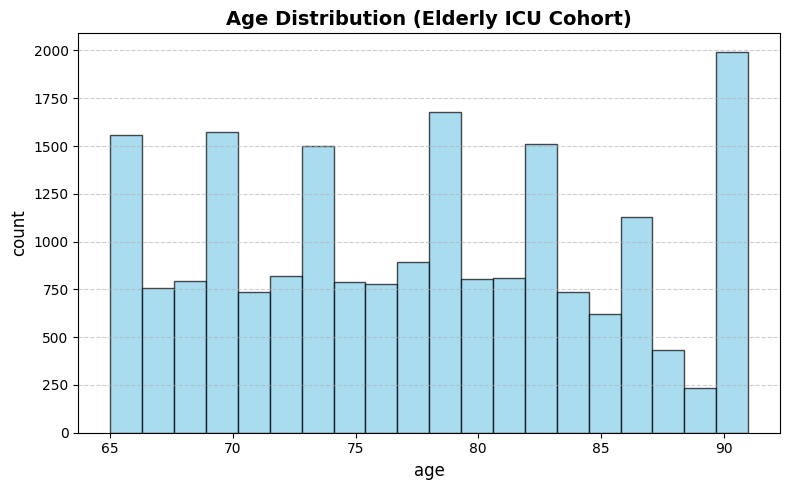

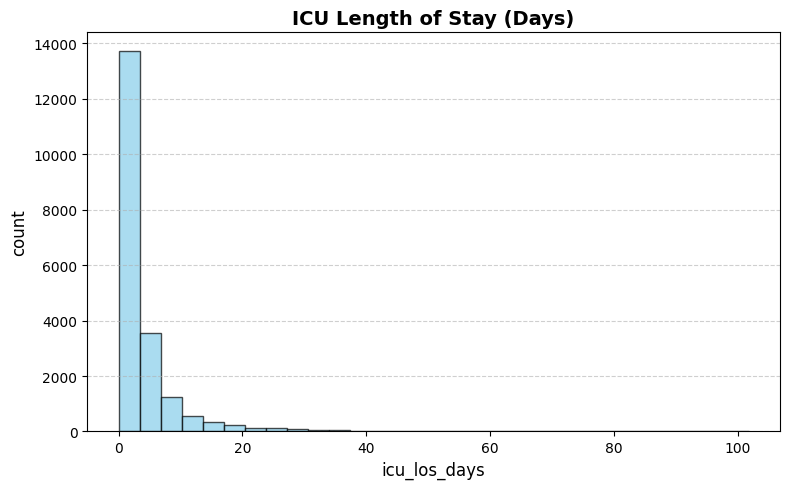

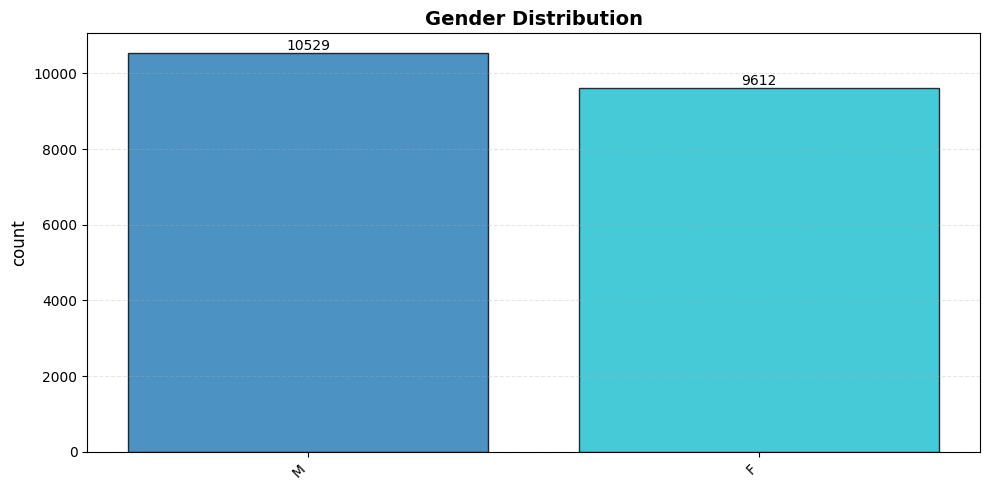

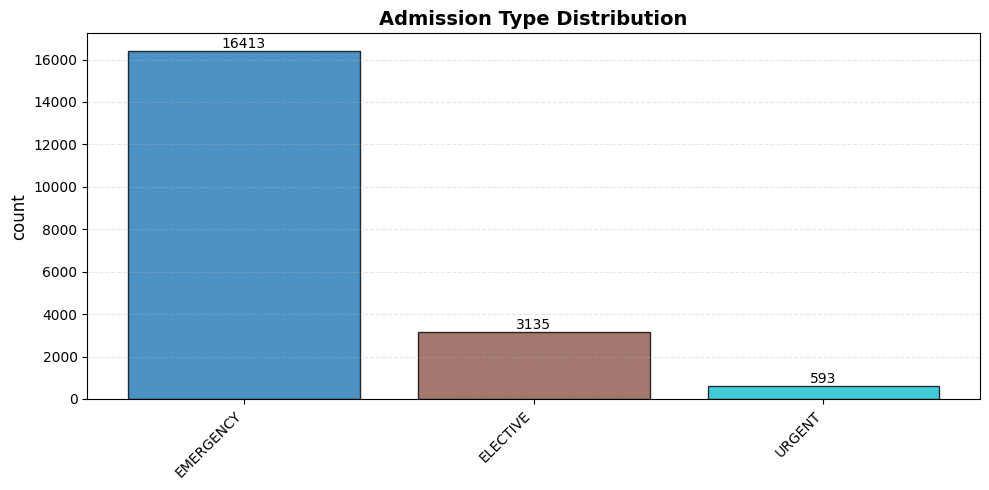

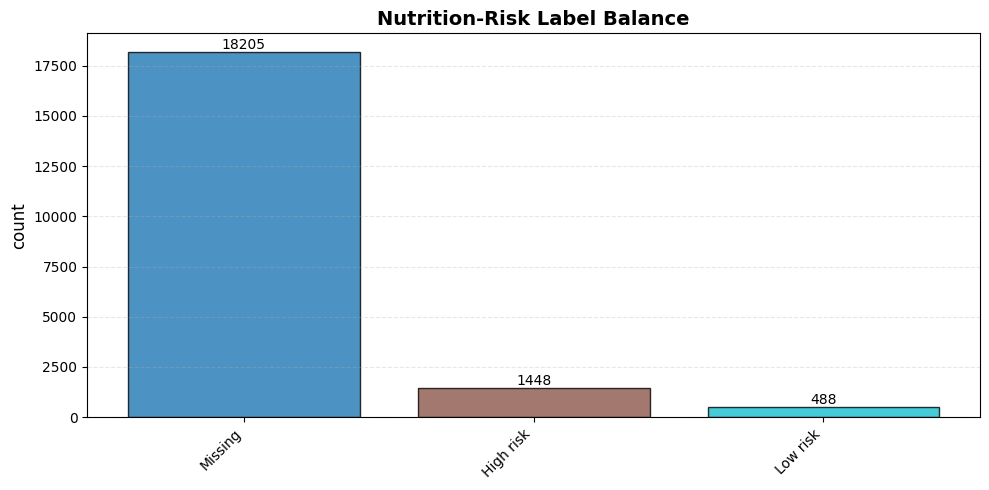

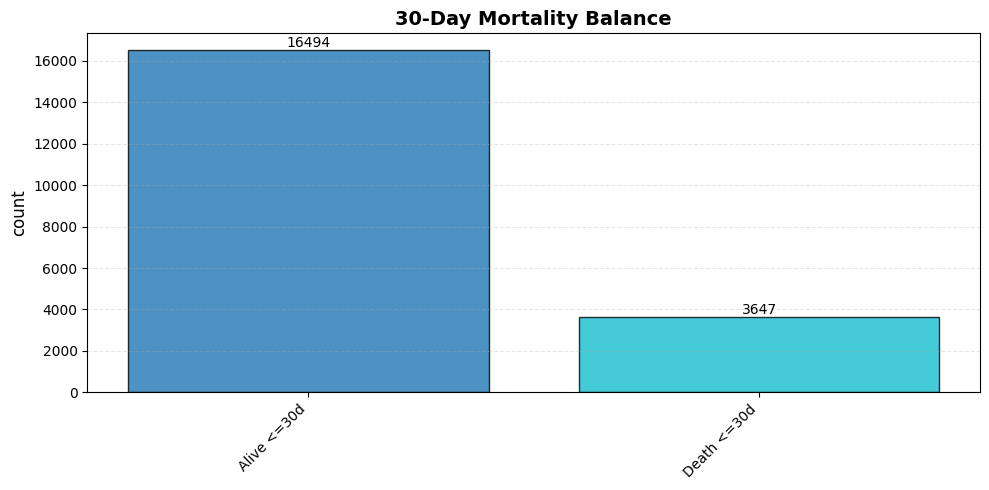

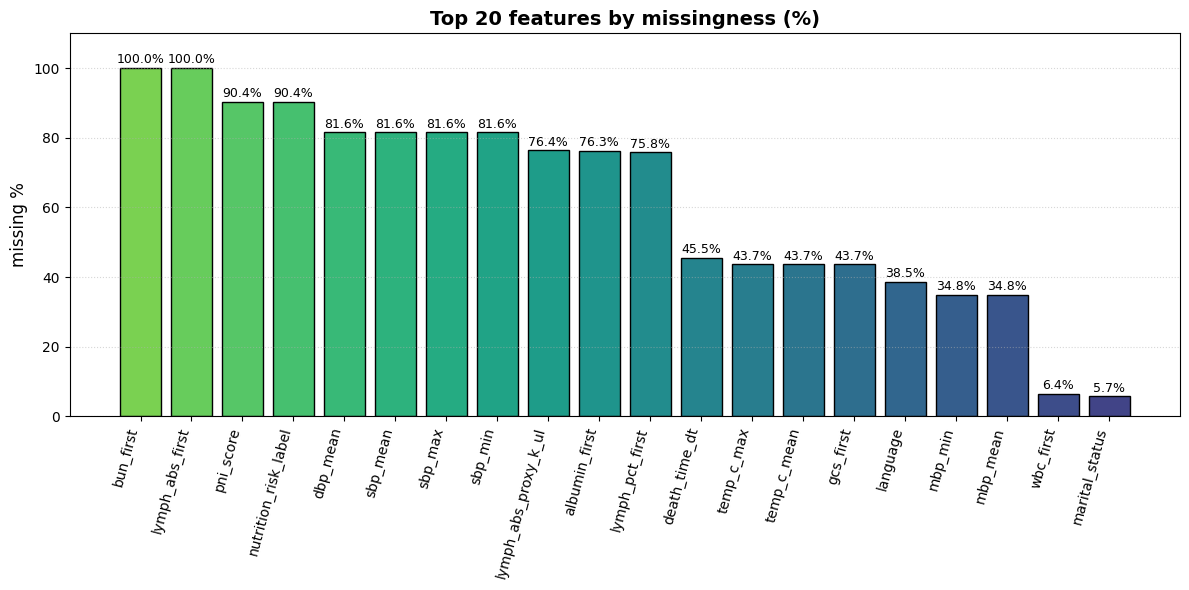


Top missingness percentages:
 bun_first               100.00
lymph_abs_first         100.00
pni_score                90.39
nutrition_risk_label     90.39
dbp_mean                 81.56
sbp_mean                 81.56
sbp_max                  81.56
sbp_min                  81.56
lymph_abs_proxy_k_ul     76.39
albumin_first            76.28
lymph_pct_first          75.85
death_time_dt            45.55
temp_c_max               43.66
temp_c_mean              43.66
gcs_first                43.65
language                 38.54
mbp_min                  34.82
mbp_mean                 34.82
wbc_first                 6.38
marital_status            5.72
dtype: float64


In [ ]:
# Plot 1: Age distribution
# This histogram shows how many patients fall into different age brackets (65 and older)
plot_hist(final_model_df["age"], "Age Distribution (Elderly ICU Cohort)", bins=20,
          save_path=PLOT_DIR / "dataset_age_distribution.png")

# Plot 2: ICU length of stay
# This chart shows the typical duration of an ICU stay in days for our cohort
plot_hist(final_model_df["icu_los_days"], "ICU Length of Stay (Days)", bins=30,
          save_path=PLOT_DIR / "dataset_icu_los_distribution.png")

# Plot 3: Gender distribution
# A simple bar chart showing the breakdown of male vs. female patients
plot_bar_from_series(final_model_df["gender"], "Gender Distribution",
                     save_path=PLOT_DIR / "dataset_gender_distribution.png")

# Plot 4: Admission type distribution
# Visualizes how patients arrived at the ICU (e.g., Emergency vs. Scheduled)
plot_bar_from_series(final_model_df["admission_type_grouped"], "Admission Type Distribution",
                     save_path=PLOT_DIR / "dataset_admission_type_distribution.png")

# Plot 5: Nutrition-risk label balance
# Shows the ratio of patients identified as 'High Risk' vs. 'Low Risk'
plot_bar_from_series(final_model_df["nutrition_risk_label"].map({0.0: "Low risk", 1.0: "High risk"}),
                     "Nutrition-Risk Label Balance",
                     save_path=PLOT_DIR / "dataset_nutrition_label_balance.png")

# Plot 6: 30-day mortality balance
# Shows the survival outcomes for the patients in our study
plot_bar_from_series(final_model_df["mortality_30d"].map({0: "Alive <=30d", 1: "Death <=30d"}),
                     "30-Day Mortality Balance",
                     save_path=PLOT_DIR / "dataset_mortality30_balance.png")

# Plot 7: Top missing features
# A critical chart ranking which patient measurements are missing most often in the raw records
missing_pct = plot_top_missing(final_model_df, top_n=20,
                               save_path=PLOT_DIR / "dataset_top_missing_features.png")
print("\nTop missingness percentages:\n", missing_pct.round(2))

,stage,n_rows,pct_of_full_cohort
0,Elderly first-ICU cohort,20141,100.00
1,With albumin_first,4777,23.72
2,With lymph input (direct or proxy),4755,23.61
3,With both albumin + lymph proxy,1936,9.61
4,Final labeled analysis cohort,1936,9.61


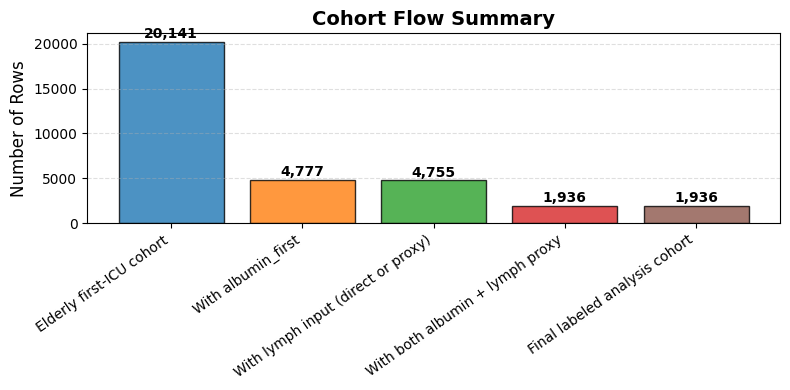

In [ ]:
# Cohort flow summary for presentation
cohort_flow = pd.DataFrame({
    "stage": [
        "Elderly first-ICU cohort",
        "With albumin_first",
        "With lymph input (direct or proxy)",
        "With both albumin + lymph proxy",
        "Final labeled analysis cohort"
    ],
    "n_rows": [
        len(final_model_df),
        final_model_df["albumin_first"].notna().sum(),
        final_model_df["lymph_abs_proxy_k_ul"].notna().sum(),
        final_model_df[
            final_model_df["albumin_first"].notna() &
            final_model_df["lymph_abs_proxy_k_ul"].notna()
        ].shape[0],
        final_model_df["nutrition_risk_label"].notna().sum()
    ]
})

cohort_flow["pct_of_full_cohort"] = (
    cohort_flow["n_rows"] / len(final_model_df) * 100
).round(2)

display(cohort_flow)
cohort_flow.to_csv(OUTPUT_DIR / "cohort_flow_summary.csv", index=False)

plt.figure(figsize=(8, 4))
# Use vibrant colors to match the refined style of earlier plots
colors = plt.cm.tab10(np.linspace(0, 0.5, len(cohort_flow)))
bars = plt.bar(cohort_flow["stage"], cohort_flow["n_rows"], color=colors, edgecolor="black", alpha=0.8)

plt.title("Cohort Flow Summary", fontsize=14, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Number of Rows", fontsize=12)

# Add count labels on top of each bar for immediate readability
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f"{int(height):,}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "cohort_flow_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Compare full cohort vs labeled cohort
full_group = final_model_df.assign(group="Full cohort")
labeled_group = final_model_df.loc[
    final_model_df["nutrition_risk_label"].notna()
].assign(group="Labeled cohort")

compare_df = pd.concat([full_group, labeled_group], ignore_index=True)

summary_compare = compare_df.groupby("group").agg(
    n_rows=("icustay_id", "count"),
    age_mean=("age", "mean"),
    age_std=("age", "std"),
    icu_los_mean=("icu_los_days", "mean"),
    mortality_30d_rate=("mortality_30d", "mean")
).round(3)

display(summary_compare)
summary_compare.to_csv(OUTPUT_DIR / "full_vs_labeled_cohort_summary.csv")

,n_rows,age_mean,age_std,icu_los_mean,mortality_30d_rate
group,,,,,
Full cohort,20141,77.606,7.788,4.081,0.181
Labeled cohort,1936,77.815,7.792,5.851,0.301


## 16.Train / validation / test split

Important anti-leakage rule:
The label is defined from albumin and lymphocyte-related variables, so we remove:
- albumin_first
- lymph_abs_first
- lymph_pct_first
- lymph_abs_proxy_k_ul
- wbc_first
- pni_score

This makes the prediction task non-trivial.

In [ ]:
# Create a working copy of the dataset for analysis
analysis_df = final_model_df.copy()

# Filter the dataset to include only patients who have a calculated nutrition risk label
analysis_df = analysis_df.loc[analysis_df["nutrition_risk_label"].notna()].copy()
# Ensure the label is stored as an integer (0 or 1)
analysis_df["nutrition_risk_label"] = analysis_df["nutrition_risk_label"].astype(int)

print_section_header("Rows available for main modeling")
print("analysis_df shape:", analysis_df.shape)

# Define the target variable we want to predict
TARGET_COL = "nutrition_risk_label"

# Group columns by their purpose to manage the feature selection process
ID_COLS = ["subject_id", "hadm_id", "icustay_id"]
TIME_COLS = ["intime_dt", "outtime_dt", "admittime_dt", "dischtime_dt", "death_time_dt"]
OUTCOME_COLS = ["mortality_30d"]
# These columns were used to create the label; we must remove them to prevent 'cheating' (data leakage)
LEAKAGE_COLS = [
    "albumin_first",
    "wbc_first",
    "lymph_pct_first",
    "lymph_abs_first",
    "lymph_abs_proxy_k_ul",
    "pni_score"
]

# Identify all columns that should not be used as predictors in the model
DROP_COLS = ID_COLS + TIME_COLS + [TARGET_COL] + OUTCOME_COLS + LEAKAGE_COLS + [
    "ethnicity", "language", "marital_status", "insurance", "admission_type", "admission_location", "discharge_location"
]

# Create a list of valid features by excluding the dropped columns
feature_cols = [c for c in analysis_df.columns if c not in DROP_COLS]

# Identify which features are categorical (text-based groups) vs numeric (measurements)
candidate_categorical = [
    "gender",
    "ethnicity_grouped",
    "language_grouped",
    "marital_status_grouped",
    "insurance_grouped",
    "admission_type_grouped",
    "admission_location_grouped"
]
categorical_features = [c for c in candidate_categorical if c in feature_cols]
numeric_features = [c for c in feature_cols if c not in categorical_features]

print("Total feature columns:", len(feature_cols))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Separate the features (X) from the target label (y)
X = analysis_df[feature_cols].copy()
y = analysis_df[TARGET_COL].copy()

# Split the data into 70% Training, 15% Validation, and 15% Testing
# 'stratify=y' ensures each set has the same proportion of high/low risk patients
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

# Split the remaining 30% equally into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

# Identify and remove any columns that have zero data in the training set
all_null_cols = [c for c in feature_cols if X_train[c].notna().sum() == 0]
print("All-null columns in training split:", all_null_cols)

if all_null_cols:
    feature_cols = [c for c in feature_cols if c not in all_null_cols]
    numeric_features = [c for c in numeric_features if c not in all_null_cols]
    categorical_features = [c for c in categorical_features if c not in all_null_cols]

    X_train = X_train[feature_cols].copy()
    X_val = X_val[feature_cols].copy()
    X_test = X_test[feature_cols].copy()

print("Feature count after removing all-null columns:", len(feature_cols))

# Print final sizes of the data splits to confirm everything is correct
print("\nSplit sizes")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Rows available for main modeling
analysis_df shape: (1936, 64)
Total feature columns: 41
Numeric features: 34
Categorical features: 7
All-null columns in training split: ['bun_first']
Feature count after removing all-null columns: 40

Split sizes
Train: (1355, 40) (1355,)
Val:   (290, 40) (290,)
Test:  (291, 40) (291,)


## 17.Preprocessing

We use:
- median imputation + scaling for numeric features
- most-frequent imputation + one-hot encoding for categorical features

This setup is simple, reproducible, and works for both Logistic Regression and XGBoost.

In [ ]:
# Initialize the preprocessing tool using our predefined numeric and categorical lists
preprocessor = build_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features
)

# Calculate and apply transformations (imputing and scaling) on the Training data
X_train_processed = preprocessor.fit_transform(X_train)
# Apply the same exact transformations to the Validation data
X_val_processed = preprocessor.transform(X_val)
# Apply the same exact transformations to the Test data
X_test_processed = preprocessor.transform(X_test)

print_section_header("Preprocessing checks")
# Count how many data points were missing before we started
print("Missing values before preprocessing (train):", int(X_train.isna().sum().sum()))

# Verify the format of the output and check if any missing values remain
if isinstance(X_train_processed, np.ndarray):
    missing_after = int(np.isnan(X_train_processed).sum())
    train_shape_after = X_train_processed.shape
else:
    # Fallback for complex data structures
    missing_after = "sparse matrix - not checked directly"
    train_shape_after = X_train_processed.shape

# Display the final shape of the data and confirm it is fully cleaned
print("Processed train shape:", train_shape_after)
print("Missing after preprocessing:", missing_after)


Preprocessing checks
Missing values before preprocessing (train): 7193
Processed train shape: (1355, 104)
Missing after preprocessing: 0


In [ ]:
def evaluate_model_on_splits(
    model,
    X_train_p,
    X_val_p,
    X_test_p,
    y_train,
    y_val,
    y_test,
    model_name
):
    """Standardizes the evaluation of a model across Training, Validation, and Test sets."""
    # Organize the data splits into a dictionary for easy looping
    split_dict = {
        "train": (X_train_p, y_train),
        "val": (X_val_p, y_val),
        "test": (X_test_p, y_test),
    }

    # Step 1: Use only the Validation set to determine the best 'cutoff' (threshold)
    # This ensures the 'test' set remains a completely unbiased final exam
    val_probs = model.predict_proba(X_val_p)[:, 1]
    best_thr, _ = find_best_threshold_by_f1(y_val, val_probs)

    rows = []
    # Step 2: Loop through each data split and calculate performance metrics
    for split_name, (X_split, y_split) in split_dict.items():
        # Get the probability scores for this specific group
        probs = model.predict_proba(X_split)[:, 1]
        # Calculate detailed accuracy stats (AUC, F1, etc.) using the chosen threshold
        metrics, _ = evaluate_binary_model(y_split, probs, threshold=best_thr)

        # Store the results for this split in a list
        rows.append({
            "model": model_name,
            "split": split_name,
            "threshold_used": round(best_thr, 4),
            **metrics
        })

    # Return a clean table (DataFrame) containing all performance results
    return pd.DataFrame(rows), best_thr

## 18.Baseline model: Logistic Regression

Why use it?
- easy to explain
- strong baseline for tabular healthcare data
- good for a tutorial because it is transparent and fast


Logistic Regression results
Best validation threshold: 0.15
roc_auc      0.716979
pr_auc       0.873676
accuracy     0.756014
precision    0.767273
recall       0.967890
f1           0.855984
threshold    0.150000
dtype: float64


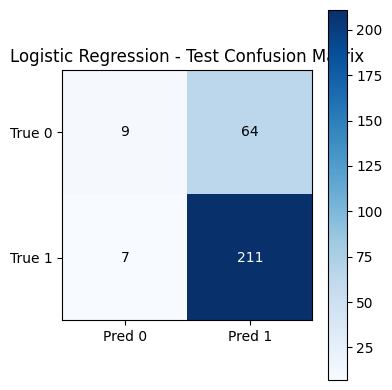

,model,split,threshold_used,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
0,LogisticRegression,train,0.15,0.797538,0.918080,0.763838,0.766334,0.984205,0.861711,0.15
1,LogisticRegression,val,0.15,0.748564,0.899900,0.748276,0.762774,0.963134,0.851324,0.15
2,LogisticRegression,test,0.15,0.716979,0.873676,0.756014,0.767273,0.967890,0.855984,0.15


In [ ]:
# Initialize the Logistic Regression model
# We use 'class_weight="balanced"' so the model gives equal importance to both high-risk and low-risk groups
log_reg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_SEED
)

# Train the model by letting it look at the patterns in our training data
log_reg_model.fit(X_train_processed, y_train)

# Calculate the probability of nutrition risk for the validation group
val_probs_lr = log_reg_model.predict_proba(X_val_processed)[:, 1]
# Find the best 'cutoff' (threshold) on the validation set to maximize our scoring accuracy (F1-score)
best_thr_lr, best_f1_lr = find_best_threshold_by_f1(y_val, val_probs_lr)

# Now, test the model on the final 'unseen' test group to see how it performs in the real world
test_probs_lr = log_reg_model.predict_proba(X_test_processed)[:, 1]
# Evaluate the model using the optimized threshold found earlier
lr_metrics, lr_cm = evaluate_binary_model(y_test, test_probs_lr, threshold=best_thr_lr)

print_section_header("Logistic Regression results")
print("Best validation threshold:", round(best_thr_lr, 3))
print(pd.Series(lr_metrics))

# Create a 'Confusion Matrix' to visualize correct vs. incorrect predictions
plot_confusion_matrix(lr_cm, title="Logistic Regression - Test Confusion Matrix",
                      save_path=PLOT_DIR / "logreg_confusion_matrix.png")

# Gather performance metrics across all data splits (Train, Val, Test) for a full report
lr_split_metrics_df, best_thr_lr = evaluate_model_on_splits(
    log_reg_model,
    X_train_processed,
    X_val_processed,
    X_test_processed,
    y_train,
    y_val,
    y_test,
    "LogisticRegression"
)

# Display the final summary table of the model's performance
display(lr_split_metrics_df)

## 19.Stronger model: XGBoost

Why use it?
- strong performance on mixed tabular clinical data
- handles nonlinearity and interactions better than Logistic Regression
- still practical for Colab if tuning is kept light


XGBoost results
Best validation threshold: 0.32
roc_auc      0.735956
pr_auc       0.879866
accuracy     0.780069
precision    0.775000
recall       0.995413
f1           0.871486
threshold    0.320000
dtype: float64


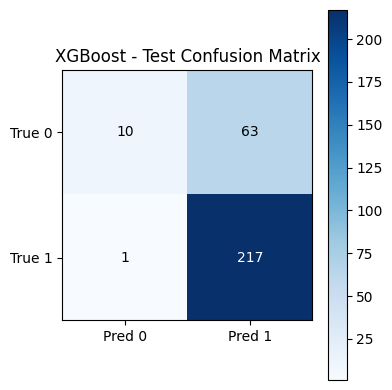

,model,split,threshold_used,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
0,XGBoost,train,0.32,0.998701,0.999560,0.888561,0.870275,1.000000,0.930638,0.32
1,XGBoost,val,0.32,0.764409,0.901228,0.796552,0.790441,0.990783,0.879346,0.32
2,XGBoost,test,0.32,0.735956,0.879866,0.780069,0.775000,0.995413,0.871486,0.32


In [ ]:
# Initialize the XGBoost Classifier with specific hyperparameters to balance complexity and accuracy
xgb_model = XGBClassifier(
    n_estimators=300,        # Build 300 sequential decision trees
    max_depth=4,             # Limit each tree to 4 levels deep to prevent overfitting
    learning_rate=0.05,      # Control the contribution of each new tree
    subsample=0.80,          # Use 80% of data for each tree to improve robustness
    colsample_bytree=0.80,   # Use 80% of features for each tree
    reg_lambda=1.0,          # Apply regularization to keep the model weights stable
    objective="binary:logistic", # Target is a binary 'Yes/No' classification
    eval_metric="logloss",   # Use log-loss to measure prediction error
    random_state=RANDOM_SEED, # Ensure consistent results across runs
    n_jobs=-1                # Use all available processors for faster training
)

# Train the XGBoost model using the patterns found in the training data
xgb_model.fit(X_train_processed, y_train)

# Calculate risk probabilities for the validation group to find the best classification threshold
val_probs_xgb = xgb_model.predict_proba(X_val_processed)[:, 1]
best_thr_xgb, best_f1_xgb = find_best_threshold_by_f1(y_val, val_probs_xgb)

# Now, test the model on the 'unseen' test group to see its real-world accuracy
test_probs_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]
# Evaluate performance using the best threshold found during the validation phase
xgb_metrics, xgb_cm = evaluate_binary_model(y_test, test_probs_xgb, threshold=best_thr_xgb)

print_section_header("XGBoost results")
print("Best validation threshold:", round(best_thr_xgb, 3))
print(pd.Series(xgb_metrics))

# Create a Confusion Matrix to visualize where the model succeeded and where it failed
plot_confusion_matrix(xgb_cm, title="XGBoost - Test Confusion Matrix",
                      save_path=PLOT_DIR / "xgb_confusion_matrix.png")

# Generate a full report of performance metrics across all data splits (Train, Val, Test)
xgb_split_metrics_df, best_thr_xgb = evaluate_model_on_splits(
    xgb_model,
    X_train_processed,
    X_val_processed,
    X_test_processed,
    y_train,
    y_val,
    y_test,
    "XGBoost"
)

# Display the final summary table comparing the model's consistency
display(xgb_split_metrics_df)

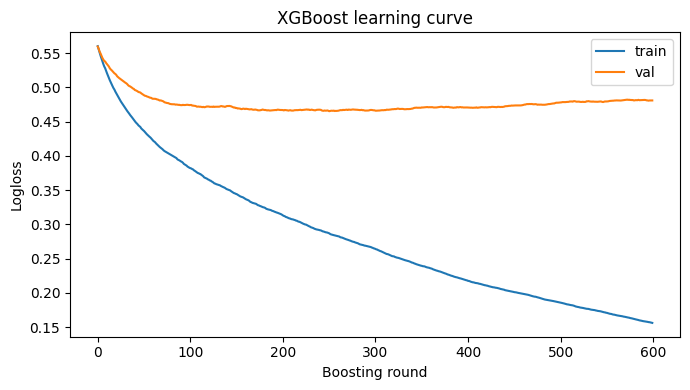

In [ ]:
# Initialize a more detailed XGBoost model for a 'tuning' experiment
xgb_tune_model = XGBClassifier(
    n_estimators=600,        # More trees to see the full learning process
    max_depth=4,             # Keep complexity controlled
    learning_rate=0.03,      # Slower learning rate for finer adjustments
    subsample=0.8,           # Use 80% of data samples per tree
    colsample_bytree=0.8,    # Use 80% of features per tree
    eval_metric="logloss",   # Focus on minimizing prediction error
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Set up an evaluation set to monitor error on both training and validation data during training
eval_set = [(X_train_processed, y_train), (X_val_processed, y_val)]
# Fit the model and track the error (logloss) at each boosting round
xgb_tune_model.fit(X_train_processed, y_train, eval_set=eval_set, verbose=False)

# Extract the error results recorded during the training process
results = xgb_tune_model.evals_result()

# Create a visualization of the learning curve to check for overfitting
plt.figure(figsize=(7, 4))
# Plot the training error (how well the model fits the known data)
plt.plot(results["validation_0"]["logloss"], label="train")
# Plot the validation error (how well the model predicts new data)
plt.plot(results["validation_1"]["logloss"], label="val")
plt.xlabel("Boosting round")
plt.ylabel("Logloss")
plt.title("XGBoost learning curve")
plt.legend()
plt.tight_layout()
# Save the plot for inclusion in reports or presentations
plt.savefig(PLOT_DIR / "xgb_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 20.Evaluation summary

We report:
- ROC-AUC
- PR-AUC
- accuracy
- precision
- recall
- F1
- confusion matrix

Why ROC-AUC alone is not enough:
Because the classes may be imbalanced, PR-AUC is also important.
For a risk-screening tutorial, recall and PR-AUC are often especially useful.

In [ ]:
# Combine the performance report cards from both models into a single master table
metrics_df = pd.concat(
    [lr_split_metrics_df, xgb_split_metrics_df],
    ignore_index=True
)

print_section_header("Model comparison table")
# Display the final side-by-side comparison of the models
display(metrics_df)

# Save this master comparison table as a CSV file for permanent record keeping
metrics_df.to_csv(METRIC_DIR / "main_task_split_metrics.csv", index=False)
print("Saved metrics:", METRIC_DIR / "main_task_split_metrics.csv")


Model comparison table


,model,split,threshold_used,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
0,LogisticRegression,train,0.15,0.797538,0.918080,0.763838,0.766334,0.984205,0.861711,0.15
1,LogisticRegression,val,0.15,0.748564,0.899900,0.748276,0.762774,0.963134,0.851324,0.15
2,LogisticRegression,test,0.15,0.716979,0.873676,0.756014,0.767273,0.967890,0.855984,0.15
3,XGBoost,train,0.32,0.998701,0.999560,0.888561,0.870275,1.000000,0.930638,0.32
4,XGBoost,val,0.32,0.764409,0.901228,0.796552,0.790441,0.990783,0.879346,0.32
5,XGBoost,test,0.32,0.735956,0.879866,0.780069,0.775000,0.995413,0.871486,0.32


Saved metrics: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/03_outputs/metrics/main_task_split_metrics.csv


## 21.Compare baseline vs XGBoost

This section gives two useful slide-ready outputs:
- comparison table
- ROC and PR curves

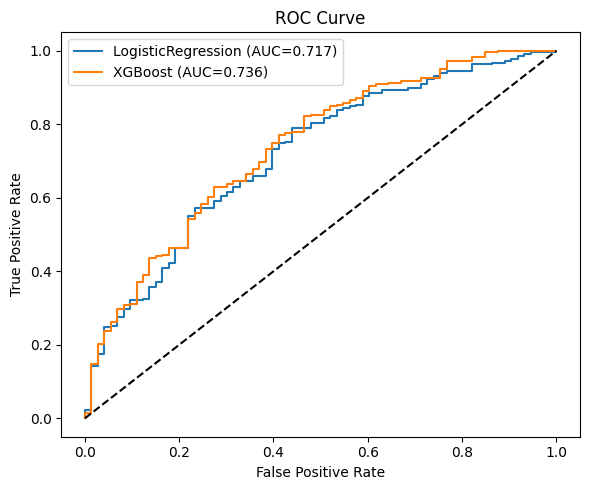

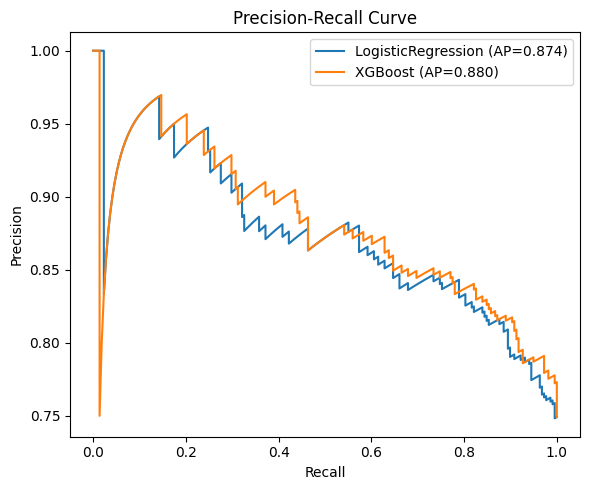


Best model by ROC-AUC
LogisticRegression


In [ ]:
# Organize the final test probabilities from both models into a dictionary for comparison
model_prob_dict = {
    "LogisticRegression": test_probs_lr,
    "XGBoost": test_probs_xgb
}

# Generate visual curves (ROC and Precision-Recall) to compare the models side-by-side
plot_roc_pr_curves(y_test, model_prob_dict, save_prefix="main_task_compare")

print_section_header("Best model by ROC-AUC")
# Automatically identify and display the name of the model that achieved the highest score
best_model_name = metrics_df.iloc[0]["model"]
print(best_model_name)

In [ ]:
# Define a smaller 'core' set of common clinical features to test model efficiency
core_features = [
    "age", "gender", "admission_type_grouped",
    "hr_mean", "mbp_mean", "rr_mean", "temp_c_mean", "spo2_mean",
    "creatinine_first", "sodium_first", "hemoglobin_first", "platelets_first",
    "diabetes_flag", "chf_flag", "ckd_flag", "copd_flag",
    "liver_disease_flag", "malignancy_flag"
]
# Filter to ensure we only include features actually present in our current data
core_features = [c for c in core_features if c in analysis_df.columns]

# Create a function to run a standardized XGBoost experiment for any given set of features
def run_feature_set_experiment(selected_features, feature_set_name):
    # Extract only the selected features for this specific trial
    X_sel = analysis_df[selected_features].copy()
    y_sel = analysis_df[TARGET_COL].copy()

    # Split data into training, validation, and test sets (consistent with main modeling)
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X_sel, y_sel,
        test_size=0.30,
        random_state=RANDOM_SEED,
        stratify=y_sel
    )
    X_va, X_te, y_va, y_te = train_test_split(
        X_tmp, y_tmp,
        test_size=0.50,
        random_state=RANDOM_SEED,
        stratify=y_tmp
    )

    # Identify categorical vs numeric features within this subset
    cat_sel = [c for c in categorical_features if c in selected_features]
    num_sel = [c for c in selected_features if c not in cat_sel]

    # Build and apply the preprocessing pipeline (imputation + scaling)
    prep = build_preprocessor(num_sel, cat_sel)
    X_tr_p = prep.fit_transform(X_tr)
    X_va_p = prep.transform(X_va)
    X_te_p = prep.transform(X_te)

    # Initialize and train a standard XGBoost model for this experiment
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    model.fit(X_tr_p, y_tr)

    # Use validation probabilities to determine the best classification threshold
    val_probs = model.predict_proba(X_va_p)[:, 1]
    best_thr, _ = find_best_threshold_by_f1(y_va, val_probs)

    # Calculate final performance scores on the unseen test data
    test_probs = model.predict_proba(X_te_p)[:, 1]
    metrics, _ = evaluate_binary_model(y_te, test_probs, threshold=best_thr)

    # Return a dictionary summarizing the results for this feature set
    return {
        "feature_set": feature_set_name,
        "n_features": len(selected_features),
        **metrics
    }

# Run the experiment for both the 'Core' set and the 'Full' set and compare results
feature_set_results = pd.DataFrame([
    run_feature_set_experiment(core_features, "Core clinical set"),
    run_feature_set_experiment(feature_cols, "Full feature set")
]).sort_values("roc_auc", ascending=False)

# Display the side-by-side performance table
display(feature_set_results)
# Save results for final report inclusion
feature_set_results.to_csv(METRIC_DIR / "feature_set_comparison.csv", index=False)

,feature_set,n_features,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
1,Full feature set,40,0.735956,0.879866,0.780069,0.775000,0.995413,0.871486,0.32
0,Core clinical set,18,0.695174,0.862744,0.762887,0.759582,1.000000,0.863366,0.27


## 22.SHAP interpretation

We run SHAP after the main models are working.
To keep runtime practical, we explain a small sample of the test set.

/tmp/ipykernel_639/2052638718.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=False)


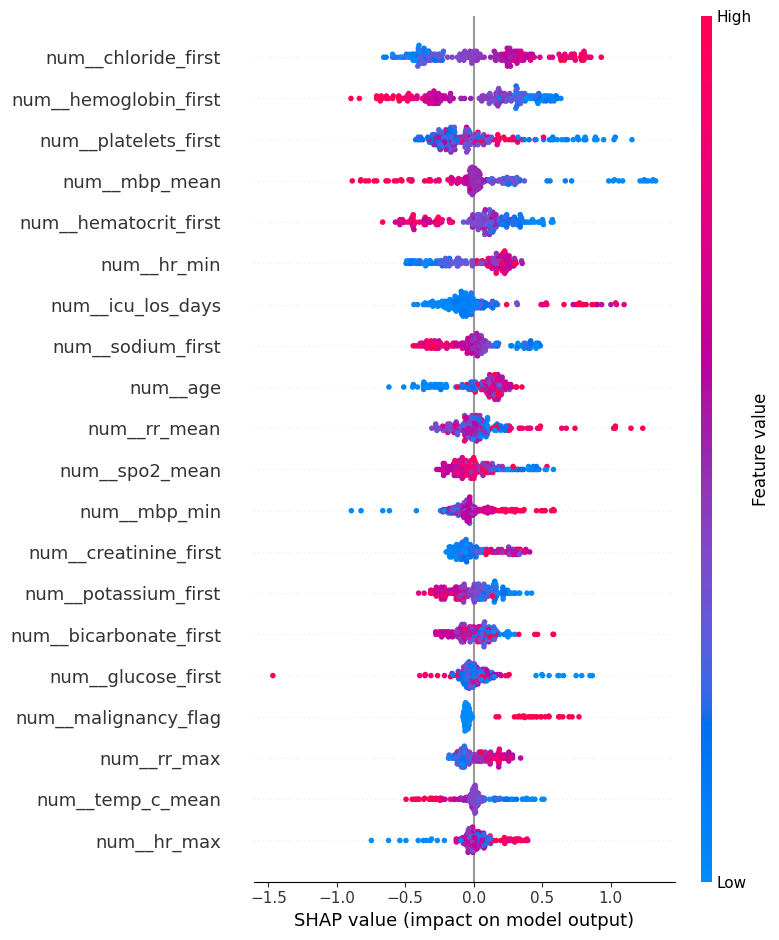

,feature,mean_abs_shap
22,num__chloride_first,0.342771
25,num__hemoglobin_first,0.336391
26,num__platelets_first,0.234431
9,num__mbp_mean,0.230272
24,num__hematocrit_first,0.227332
3,num__hr_min,0.213090
1,num__icu_los_days,0.182747
20,num__sodium_first,0.177828
0,num__age,0.164357
11,num__rr_mean,0.143532


In [ ]:
if RUN_SHAP:
    # Use the preprocessor to get the final names of all features after they were transformed (e.g., one-hot encoding)
    feature_names_after_preprocessing = preprocessor.get_feature_names_out()

    # Convert the processed test data into a readable table with these feature names
    X_test_processed_df = pd.DataFrame(
        X_test_processed,
        columns=feature_names_after_preprocessing,
        index=X_test.index
    )

    # Pick a random sample of 200 patients to analyze (this keeps the calculation fast while remaining representative)
    shap_sample_n = min(200, len(X_test_processed_df))
    X_shap = X_test_processed_df.sample(n=shap_sample_n, random_state=RANDOM_SEED)

    # Initialize the SHAP 'X-ray' tool for our XGBoost model
    explainer = shap.TreeExplainer(xgb_model)
    # Calculate how much each feature contributed to the risk score for our sample group
    shap_values = explainer.shap_values(X_shap)

    # Create a Summary Plot to visualize and rank the most influential features
    plt.figure()
    shap.summary_plot(shap_values, X_shap, show=False)
    plt.tight_layout()
    # Save the plot for our final report
    plt.savefig(PLOT_DIR / "xgb_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Calculate the average 'impact' (importance) of each feature across the group
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values(by="mean_abs_shap", ascending=False)

    # Display the top 20 most important predictors
    display(shap_importance_df.head(20))
    # Save this importance table for record-keeping
    shap_importance_df.to_csv(METRIC_DIR / "xgb_shap_importance.csv", index=False)
else:
    print("RUN_SHAP=False -> SHAP skipped.")

## 23.Extension analysis: 30-day mortality

Simple tutorial-friendly extension:
1. Compare mortality rates by nutrition-risk group
2. Test whether adding the PNI signal improves a simple mortality model


Mortality rate by nutrition-risk group


,mean,count
nutrition_risk_label,,
0,0.202869,488
1,0.333564,1448



Extension model comparison


,model,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
0,Mortality_Base,0.682730,0.505954,0.650602,0.438596,0.571429,0.496278,0.5
1,Mortality_BasePlusPNI,0.691471,0.521024,0.660929,0.450450,0.571429,0.503778,0.5


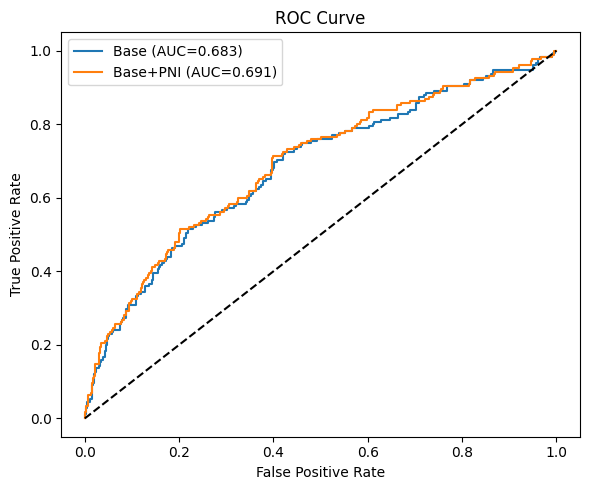

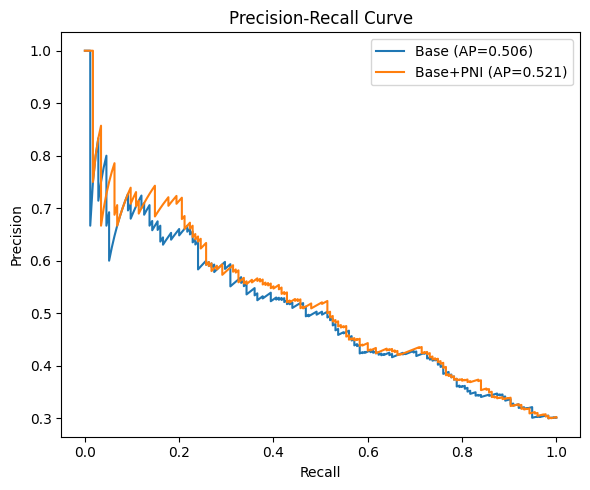

In [ ]:
if RUN_EXTENSION:
    # Prepare a fresh copy of the data for mortality analysis
    extension_df = final_model_df.copy()
    # Ensure we only include patients who have both a nutrition risk label and known 30-day survival status
    extension_df = extension_df.loc[
        extension_df["nutrition_risk_label"].notna() &
        extension_df["mortality_30d"].notna()
    ].copy()

    # Convert labels to standard integers for calculation
    extension_df["nutrition_risk_label"] = extension_df["nutrition_risk_label"].astype(int)
    extension_df["mortality_30d"] = extension_df["mortality_30d"].astype(int)

    print_section_header("Mortality rate by nutrition-risk group")
    # Calculate the actual percentage of patients who died within 30 days in each risk group
    mortality_by_group = extension_df.groupby("nutrition_risk_label")["mortality_30d"].agg(["mean", "count"])
    display(mortality_by_group)

    # Define the base set of features used for mortality prediction (excluding direct nutrition markers)
    base_mortality_feature_cols = feature_cols.copy()

    # Define an enhanced feature set that adds the PNI nutrition score to the base data
    plus_pni_feature_cols = base_mortality_feature_cols + ["pni_score"]

    # Separate our features and target outcome (30-day mortality)
    X_m_base = extension_df[base_mortality_feature_cols].copy()
    X_m_plus = extension_df[plus_pni_feature_cols].copy()
    y_m = extension_df["mortality_30d"].copy()

    # Split data into training and testing sets for both the 'Base' and 'Enhanced' experiments
    Xmb_train, Xmb_test, ymb_train, ymb_test = train_test_split(
        X_m_base, y_m, test_size=0.30, random_state=RANDOM_SEED, stratify=y_m
    )
    Xmp_train, Xmp_test, ymp_train, ymp_test = train_test_split(
        X_m_plus, y_m, test_size=0.30, random_state=RANDOM_SEED, stratify=y_m
    )

    # Build and apply preprocessing (scaling/imputing) for both feature sets
    base_cat = [c for c in categorical_features if c in X_m_base.columns]
    base_num = [c for c in X_m_base.columns if c not in base_cat]

    plus_cat = [c for c in categorical_features if c in X_m_plus.columns]
    plus_num = [c for c in X_m_plus.columns if c not in plus_cat]

    base_prep = build_preprocessor(base_num, base_cat)
    plus_prep = build_preprocessor(plus_num, plus_cat)

    Xmb_train_proc = base_prep.fit_transform(Xmb_train)
    Xmb_test_proc = base_prep.transform(Xmb_test)

    Xmp_train_proc = plus_prep.fit_transform(Xmp_train)
    Xmp_test_proc = plus_prep.transform(Xmp_test)

    # Initialize and train mortality prediction models (Base vs Base + Nutrition Score)
    mort_base_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)
    mort_plus_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)

    mort_base_model.fit(Xmb_train_proc, ymb_train)
    mort_plus_model.fit(Xmp_train_proc, ymp_train)

    # Evaluate how well each model predicts survival on unseen test data
    mort_base_probs = mort_base_model.predict_proba(Xmb_test_proc)[:, 1]
    mort_plus_probs = mort_plus_model.predict_proba(Xmp_test_proc)[:, 1]

    mort_base_metrics, _ = evaluate_binary_model(ymb_test, mort_base_probs, threshold=0.5)
    mort_plus_metrics, _ = evaluate_binary_model(ymp_test, mort_plus_probs, threshold=0.5)

    # Compile side-by-side performance results
    extension_metrics_df = pd.DataFrame([
        {"model": "Mortality_Base", **mort_base_metrics},
        {"model": "Mortality_BasePlusPNI", **mort_plus_metrics}
    ])

    print_section_header("Extension model comparison")
    display(extension_metrics_df)

    # Save the final extension metrics for the report
    extension_metrics_df.to_csv(METRIC_DIR / "extension_mortality_model_metrics.csv", index=False)

    # Generate visual curves (ROC and PR) to compare mortality prediction accuracy
    plot_roc_pr_curves(
        ymb_test,
        {"Base": mort_base_probs, "Base+PNI": mort_plus_probs},
        save_prefix="extension_mortality_compare"
    )
else:
    print("RUN_EXTENSION=False -> extension analysis skipped.")

In [ ]:
display(mortality_by_group)

# Extract mortality rates for each group from our previously calculated table
mortality_low_risk = mortality_by_group.loc[0, 'mean']
mortality_high_risk = mortality_by_group.loc[1, 'mean']

# Calculate the absolute difference (the 'gap') in survival rates
absolute_diff = mortality_high_risk - mortality_low_risk

# Calculate the Relative Risk (how many times more likely death is in the high-risk group)
relative_risk = mortality_high_risk / mortality_low_risk

print(f"\n--- Further Insights ---")
print(f"Absolute difference in 30-day mortality rate: {absolute_diff:.2%} (High risk - Low risk)")
print(f"Relative risk of 30-day mortality: {relative_risk:.2f} (High risk vs. Low risk)")
print("\nInterpretation:")
print(f"Patients identified as high nutrition risk have an absolute mortality rate that is {absolute_diff:.2%} higher than those identified as low nutrition risk.")
print(f"They are also {relative_risk:.2f} times more likely to experience 30-day mortality compared to the low nutrition risk group.")

,mean,count
nutrition_risk_label,,
0,0.202869,488
1,0.333564,1448



--- Further Insights ---
Absolute difference in 30-day mortality rate: 13.07% (High risk - Low risk)
Relative risk of 30-day mortality: 1.64 (High risk vs. Low risk)

Interpretation:
Patients identified as high nutrition risk have an absolute mortality rate that is 13.07% higher than those identified as low nutrition risk.
They are also 1.64 times more likely to experience 30-day mortality compared to the low nutrition risk group.


## 24.Save outputs

We save:
- metrics
- plots
- feature schema
- notebook-ready summaries

In [ ]:
# Save the feature schema (the 'blueprint' of which data went into our model)
feature_schema = {
    "target": TARGET_COL, # The risk label we predicted
    "numeric_features": numeric_features, # All physical measurements used
    "categorical_features": categorical_features, # All text-based categories used
    "all_model_features": feature_cols, # The full list of predictors
    "dropped_for_leakage": LEAKAGE_COLS, # Features we intentionally removed to prevent 'cheating'
    "id_columns": ID_COLS,
    "time_columns": TIME_COLS,
    "outcome_columns": OUTCOME_COLS
}

# Export the schema to a JSON file for easy reading by other programs
with open(OUTPUT_DIR / "feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2)

print("Saved:", OUTPUT_DIR / "feature_schema.json")

# Save a concise summary of the final dataset used for analysis
dataset_summary = {
    "final_model_df_shape": list(final_model_df.shape),
    "analysis_df_shape": list(analysis_df.shape),
    "nutrition_risk_positive_rate": float(analysis_df["nutrition_risk_label"].mean()),
    "mortality_30d_rate_final_table": float(final_model_df["mortality_30d"].mean()),
    "random_seed": RANDOM_SEED
}

with open(OUTPUT_DIR / "dataset_summary.json", "w") as f:
    json.dump(dataset_summary, f, indent=2)

print("Saved:", OUTPUT_DIR / "dataset_summary.json")
print("Plots saved in:", PLOT_DIR)
print("Metrics saved in:", METRIC_DIR)

Saved: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/03_outputs/feature_schema.json
Saved: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/03_outputs/dataset_summary.json
Plots saved in: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/03_outputs/plots
Metrics saved in: /content/drive/MyDrive/msai_assignment4_mimic_nutrition/03_outputs/metrics


## 25.Reproducibility notes

Key reproducibility choices in this notebook:
- fixed random seed
- separate extraction and modeling phases
- cached Parquet reuse
- clear anti-leakage feature exclusions
- light hyperparameter tuning for practical Colab runtime

Reminder:
Do not redistribute raw MIMIC-III data.

In [ ]:
reproducibility_notes = """
Reproducibility notes
1. Random seed is fixed for Python, NumPy, and model training where applicable.
2. BigQuery extraction is separated from modeling via cached Parquet.
3. Main anti-leakage rule: label-defining albumin and lymphocyte variables are excluded from the predictor set.
4. XGBoost tuning is intentionally light to keep runtime practical.
5. Reruns may still vary slightly because some model internals and compute environments can differ.
6. Do not share raw MIMIC data, raw extracts, or identifiable outputs in public repositories or third-party APIs.
"""

print(reproducibility_notes)

with open(OUTPUT_DIR / "reproducibility_notes.txt", "w") as f:
    f.write(reproducibility_notes)


Reproducibility notes
1. Random seed is fixed for Python, NumPy, and model training where applicable.
2. BigQuery extraction is separated from modeling via cached Parquet.
3. Main anti-leakage rule: label-defining albumin and lymphocyte variables are excluded from the predictor set.
4. XGBoost tuning is intentionally light to keep runtime practical.
5. Reruns may still vary slightly because some model internals and compute environments can differ.
6. Do not share raw MIMIC data, raw extracts, or identifiable outputs in public repositories or third-party APIs.



## 26.Limitations

This tutorial keeps the design intentionally simple.
That makes it more teachable, but also introduces limitations.

In [ ]:
limitations_text = """
Limitations
1. The main label is a PNI-style proxy, not a full bedside nutrition assessment.
2. If absolute lymphocyte count is unavailable, the proxy uses WBC and lymphocyte percentage, which is an approximation.
3. This is a single-center retrospective EHR dataset.
4. The tutorial uses only structured first-24-hour data and does not use notes or time-series sequence models.
5. The extension to mortality is designed for teaching, not for clinical deployment claims.
"""

print(limitations_text)

with open(OUTPUT_DIR / "limitations.txt", "w") as f:
    f.write(limitations_text)


Limitations
1. The main label is a PNI-style proxy, not a full bedside nutrition assessment.
2. If absolute lymphocyte count is unavailable, the proxy uses WBC and lymphocyte percentage, which is an approximation.
3. This is a single-center retrospective EHR dataset.
4. The tutorial uses only structured first-24-hour data and does not use notes or time-series sequence models.
5. The extension to mortality is designed for teaching, not for clinical deployment claims.



## 27.Key takeaways

This notebook teaches a full workflow:
- extract a cohort from BigQuery
- engineer a transparent proxy label
- avoid leakage
- compare interpretable ML models
- visualize the dataset
- test a clinically meaningful extension outcome

In [5]:
takeaways_text = """
Key takeaways
1. BigQuery is best for heavy cohort and feature extraction.
2. Colab is best for modeling, evaluation, and explanation.
3. Cached Parquet makes the project much easier to rerun.
4. Label leakage must be handled explicitly when the label is derived from lab variables.
5. A simple, well-explained notebook is better for this assignment than an overcomplicated clinical pipeline.
"""

print(takeaways_text)

with open(OUTPUT_DIR / "key_takeaways.txt", "w") as f:
    f.write(takeaways_text)


Key takeaways
1. BigQuery is best for heavy cohort and feature extraction.
2. Colab is best for modeling, evaluation, and explanation.
3. Cached Parquet makes the project much easier to rerun.
4. Label leakage must be handled explicitly when the label is derived from lab variables.
5. A simple, well-explained notebook is better for this assignment than an overcomplicated clinical pipeline.

